In [6]:
"""
Load EOM outputs and compute 1D (ω3, τ3) and 2D (ω3, ω1) spectra.

"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from numpy.fft import fft, fftshift, fftfreq
# Configure LaTeX fonts using rcParams
mpl.rcParams.update({
    'font.size': 14,         # Set font size
    'font.family': 'serif',  # Use serif font
    'text.usetex': True       # Use LaTeX to render text
})

In [7]:
# -------------------
# Load arrays & metadata
# -------------------
alpha11n1 = np.load("alpha11n1.npy")  # shape (N_t, N_tau2), complex
alpha1n11 = np.load("alpha1n11.npy")
alphan111 = np.load("alphan111.npy")
alpha001  = np.load("alpha001.npy")

times = np.load("times.npy")
tau3_values = np.load("tau3_values.npy")

with open("meta.json", "r") as f:
    meta = json.load(f)

kappa = meta["kappa"]

# grid steps (used for frequency axes)
dt   = float(np.mean(np.diff(times)))
dtau = float(np.mean(np.diff(tau3_values)))

In [8]:
N_t, N_tau2 = alpha11n1.shape

# -------------------
# Frequencies (rad/time-unit) with shift, sign conventions match script
# -------------------
freq_t    = -fftshift(2*np.pi*fftfreq(N_t,    d=dt))     # ω3
freq_tau2 = -fftshift(2*np.pi*fftfreq(N_tau2, d=dtau))   # ω2

# -------------------
# 1) FT along time t (axis=0) → (ω3, τ2)
# -------------------
dft_alpha11n1_t = fftshift(fft(alpha11n1, axis=0), axes=0)
dft_alpha1n11_t = fftshift(fft(alpha1n11, axis=0), axes=0)
dft_alphan111_t = fftshift(fft(alphan111, axis=0), axes=0)
dft_resultslin  = fftshift(fft(alpha001,  axis=0), axes=0)  

# -------------------
# 2) Multiply in (ω3, τ2) domain
# -------------------
Z1_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin) * dft_alpha11n1_t)
Z2_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin) * dft_alpha1n11_t)
Z3_ttau = (kappa/2.0)**2 * np.real(np.conjugate(dft_resultslin) * dft_alphan111_t)

# -------------------
# 3) FT along τ2 (axis=1) → (ω3, ω2)
# -------------------
dft_alpha11n1 = fftshift(fft(Z1_ttau, axis=1), axes=1)*100
dft_alpha1n11 = fftshift(fft(Z2_ttau, axis=1), axes=1)
dft_alphan111 = fftshift(fft(Z3_ttau, axis=1), axes=1)

# Choose representations (real vs abs etc.)
Z1plot = np.real(dft_alpha11n1)
Z2plot = np.real(dft_alpha1n11)
Z3plot = np.real(dft_alphan111)


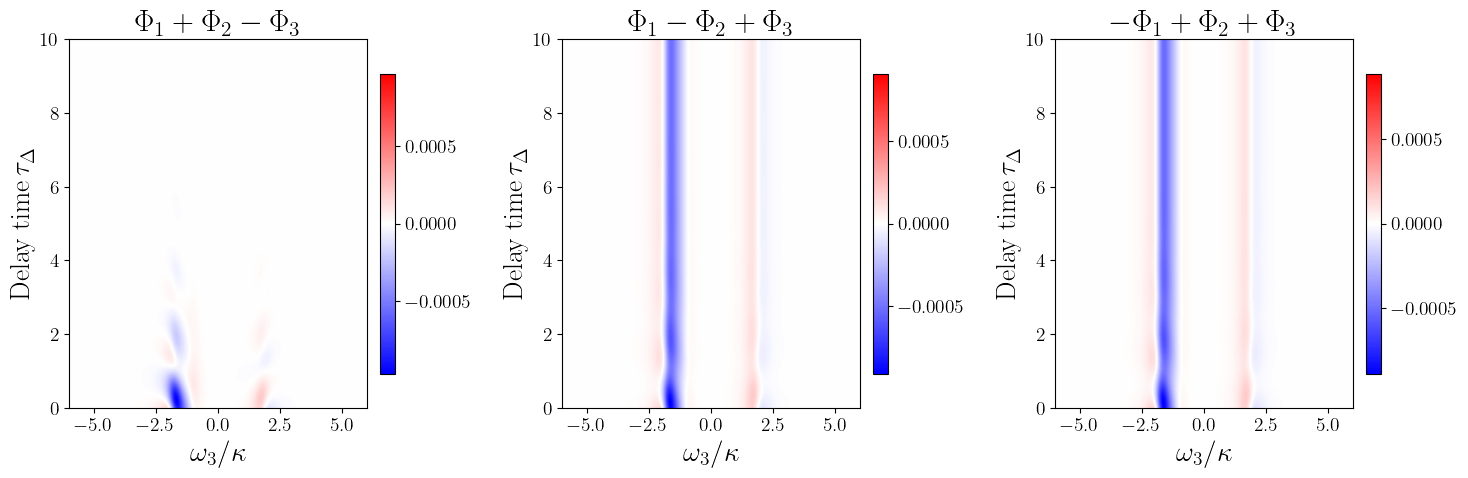

In [9]:
# Limits for color
vmax1 = np.nanmax(np.abs(Z1_ttau))
vmax2 = np.nanmax(np.abs(Z2_ttau))
vmax3 = np.nanmax(np.abs(Z3_ttau))

vmin1, vmin2, vmin3 = -vmax1, -vmax2, -vmax3
# Or use actual τ3 values:
tau3_vals = np.arange(N_tau2) * dtau
extent_ttau = [freq_t[0], freq_t[-1], tau3_vals[0], tau3_vals[-1]]

# -----------------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Z1
im1 = axs[0].imshow(
    Z1_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin1, vmax=vmax1
)
axs[0].set_title(r'$\Phi_1+\Phi_2-\Phi_3$', fontsize=22)
axs[0].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[0].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[0].set_xlim(-6,6)
fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)

# Z2
im2 = axs[1].imshow(
    Z2_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin2, vmax=vmax2
)
axs[1].set_title(r'$\Phi_1-\Phi_2+\Phi_3$', fontsize=22)
axs[1].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[1].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[1].set_xlim(-6,6)
fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)

# Z3
im3 = axs[2].imshow(
    Z3_ttau.T, extent=extent_ttau, aspect='auto', cmap='bwr', origin='lower',
    vmin=vmin3, vmax=vmax3
)
axs[2].set_title(r'$-\Phi_1+\Phi_2+\Phi_3$', fontsize=22)
axs[2].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[2].set_ylabel(r'Delay time\,$\tau_\Delta$', fontsize=20)
axs[2].set_xlim(-6,6)
fig.colorbar(im3, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

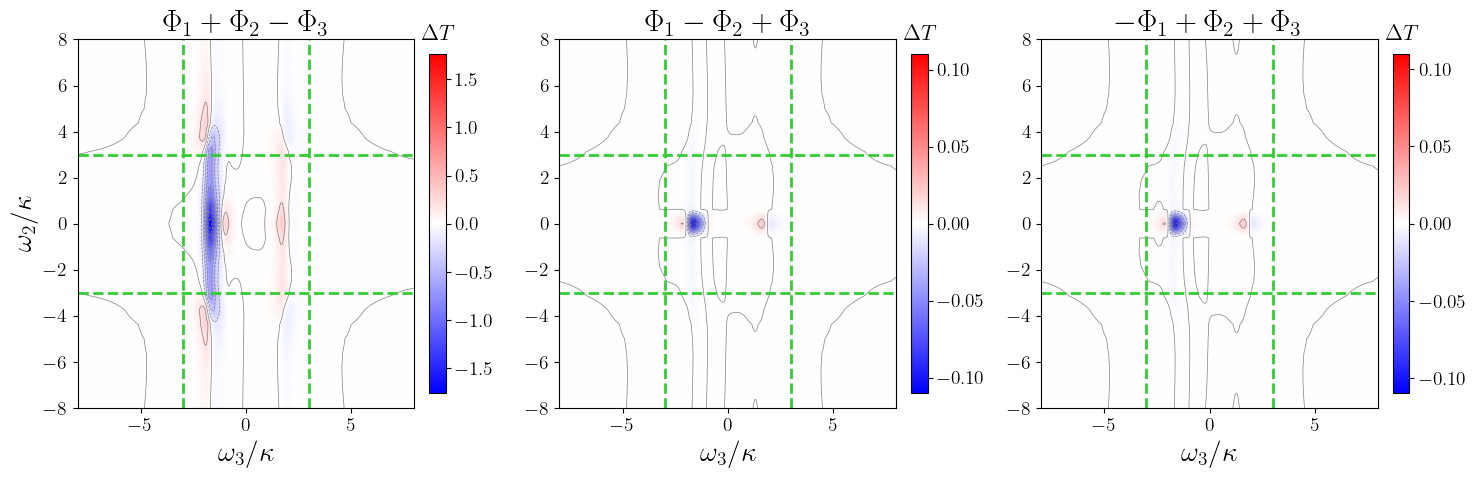

In [10]:
# For each Z*, get its own max absolute value
vmax1 = np.abs(Z1plot).max()
vmax2 = np.abs(Z2plot).max()
vmax3 = np.abs(Z3plot).max()

vmin1, vmin2, vmin3 = -vmax1, -vmax2, -vmax3

fig, axs = plt.subplots(1, 3, figsize=(15, 5))


# Build an 'extent' so imshow has real frequency axis.
# freq_t runs from freq_t[0] to freq_t[-1] (negative to positive)
# freq_tau2 from freq_tau2[0] to freq_tau2[-1].
extent = [freq_t[0], freq_t[-1],  freq_tau2[0], freq_tau2[-1]]

###################################
# Plot Z1 with its own vmin/vmax
###################################
im1 = axs[0].imshow(
    Z1plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin1,
    vmax=vmax1
)
contour1 = axs[0].contour(
    Z1plot.T,
    levels=10,
    colors='gray',
    linewidths=0.5,
    extent=extent
)
axs[0].set_title(r'$\Phi_1+\Phi_2-\Phi_3$', fontsize=22)
axs[0].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[0].set_ylabel(r'$\omega_2/\kappa$', fontsize=20)
axs[0].set_xlim(-8, 8)
axs[0].set_ylim(-8, 8)

# -----------------------------------
# Create first colorbar
# -----------------------------------
cbar1 = fig.colorbar(im1, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)
# Use set_title to add a label on top of the colorbar
cbar1.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

###################################
# Plot Z2 with its own vmin/vmax
###################################
im2 = axs[1].imshow(
    Z2plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin2,
    vmax=vmax2
)
contour2 = axs[1].contour(
    Z2plot.T,
    levels=10,
    colors='gray',
    linewidths=0.5,
    extent=extent
)
axs[1].set_title(r'$\Phi_1-\Phi_2+\Phi_3$', fontsize=22)
axs[1].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[1].set_xlim(-8, 8)
axs[1].set_ylim(-8, 8)


# -----------------------------------
# Create second colorbar
# -----------------------------------
cbar2 = fig.colorbar(im2, ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar2.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

###################################
# Plot Z3 with its own vmin/vmax
###################################
im3 = axs[2].imshow(
    Z3plot.T,
    extent=extent,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin3,
    vmax=vmax3
)
contour3 = axs[2].contour(
    Z3plot.T,
    levels=10,
    colors='gray',
    linewidths=0.5,
    extent=extent
)
axs[2].set_title(r'$-\Phi_1+\Phi_2+\Phi_3$', fontsize=22)
axs[2].set_xlabel(r'$\omega_3/\kappa$', fontsize=20)
axs[2].set_xlim(-8, 8)
axs[2].set_ylim(-8, 8)


for ax in axs:
    ax.axhline(y=3, color='limegreen', linestyle='--', lw=2)
    ax.axhline(y=-3, color='limegreen', linestyle='--', lw=2)
    ax.axvline(x=3, color='limegreen', linestyle='--', lw=2)
    ax.axvline(x=-3, color='limegreen', linestyle='--', lw=2)
    
    

# -----------------------------------
# Create third colorbar
# -----------------------------------
cbar3 = fig.colorbar(im3, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar3.ax.set_title(r'$\Delta T$', pad=10, fontsize=16)

plt.tight_layout()
plt.show()

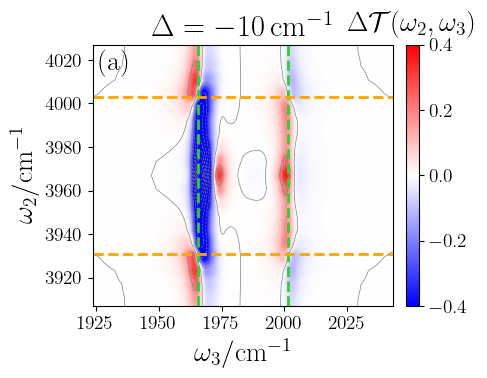

In [11]:
# -------------------
# Normalize ΔT so that max |ΔT| = 1
# -------------------
norm = np.nanmax(np.abs(Z1plot))
if not np.isfinite(norm) or norm == 0.0:
    norm = 1e-12
Z1plot_n = Z1plot 

Z1plot_n = Z1plot

absmax = np.nanmax(np.abs(Z1plot_n))
if not np.isfinite(absmax) or absmax == 0.0:
    absmax = 1e-12

vmin1, vmax1 = -0.4, 0.4

# -------------------
# Rotating-frame shifts + unit conversion
# everything currently in units of 10 cm^{-1} -> multiply axes by 10
# and apply offsets: x += 1983, y += 2*1983
# -------------------
scale = 10.0
x_shift = 1983.5
y_shift = 2.0 * 1983.5  # 3966

# extent = [xmin, xmax, ymin, ymax]
extent_sf = [
    extent[0] * scale + x_shift,
    extent[1] * scale + x_shift,
    extent[2] * scale + y_shift,
    extent[3] * scale + y_shift,
]

# Transform dashed-line positions (original values were in the unscaled/unshifted frame)
x_lines = [(1.8 * scale + x_shift), (-1.8 * scale + x_shift)]
y_lines = [(2*1.8 * scale + y_shift), (-2*1.8 * scale + y_shift)]

# Also transform limits
xlim_sf = (-6.0 * scale + x_shift, 6.0 * scale + x_shift)
ylim_sf = (-6.0 * scale + y_shift, 6.0 * scale + y_shift)

# Transform tick locations 
xticks_sf = [(-3.0 * scale + x_shift), (0.0 * scale + x_shift), (3.0 * scale + x_shift)]
yticks_sf = [(-6.0 * scale + y_shift), (0.0 * scale + y_shift), (6.0 * scale + y_shift)]

# -------------------
# Create a single-axes figure
# -------------------
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

im1 = ax.imshow(
    Z1plot_n.T,
    extent=extent_sf,
    aspect='auto',
    cmap='bwr',
    origin='lower',
    vmin=vmin1,
    vmax=vmax1
)

#Add contour lines
contour1 = ax.contour(
    Z1plot.T,
    levels=10,
    colors='gray',
    linewidths=0.5,
    extent=extent_sf
)



ax.set_title(r'$\Delta=-10\,\mathrm{cm}^{-1}$', fontsize=22)
ax.set_xlabel(r'$\omega_3/\mathrm{cm}^{-1}$', fontsize=20)
ax.set_ylabel(r'$\omega_2/\mathrm{cm}^{-1}$', fontsize=20)
ax.set_xlim(*xlim_sf)
ax.set_ylim(*ylim_sf)

# Panel label (top-left corner)
ax.text(
    0.02, 0.98,
    r'$\mathrm{(a)}$',
    transform=ax.transAxes,
    fontsize=20,
    va='top',
    ha='left'
)



# Keep dashed lines (but no labels)
ax.axvline(x=x_lines[0],  color='limegreen', linestyle='--', lw=2.0)
ax.axvline(x=x_lines[1], color='limegreen', linestyle='--', lw=2.0)
ax.axhline(y=y_lines[0],  color='orange', linestyle='--', lw=2.0)
ax.axhline(y=y_lines[1], color='orange', linestyle='--', lw=2.0)



# Add a colorbar for this single plot
cbar = fig.colorbar(im1, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
cbar.ax.set_title(r'$\Delta\mathcal{T}(\omega_2,\omega_3) $', pad=10, fontsize=20)

plt.tight_layout()
plt.savefig("dqc_nonchron_1.pdf", bbox_inches='tight')
plt.show()

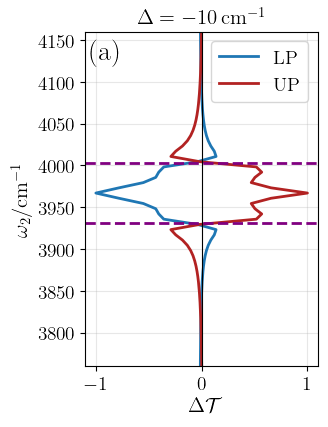

In [12]:
# -------------------
# Build scaled axes
# -------------------
extent_sf = [
    extent[0] * scale + x_shift,
    extent[1] * scale + x_shift,
    extent[2] * scale + y_shift,
    extent[3] * scale + y_shift,
]

nx, ny = Z1plot_n.shape
x_axis = np.linspace(extent_sf[0], extent_sf[1], nx)
y_axis = np.linspace(extent_sf[2], extent_sf[3], ny)

# LP (lower frequency) and UP (higher frequency)
x_LP = (-1.8 * scale + x_shift)
x_UP = ( 1.8 * scale + x_shift)

i_LP = np.argmin(np.abs(x_axis - x_LP))
i_UP = np.argmin(np.abs(x_axis - x_UP))

cut_LP = Z1plot_n[i_LP, :]
cut_UP = Z1plot_n[i_UP, :]

# Normalize each cut
def norm(v):
    m = np.nanmax(np.abs(v))
    if not np.isfinite(m) or m == 0:
        m = 1e-12
    return v / m

cut_LP_n = norm(cut_LP)
cut_UP_n = norm(cut_UP)

# Double-excitation (orange) horizontal energies
y_DQ_high = ( 2*1.8 * scale + y_shift)
y_DQ_low  = (-2*1.8 * scale + y_shift)

# -------------------
# Plot cuts
# -------------------
fig, ax = plt.subplots(figsize=(3.5, 4.5))

ax.plot(cut_LP_n, y_axis, lw=2, label='LP')
ax.plot(cut_UP_n, y_axis, lw=2, label='UP', color="firebrick")

# Zero line
ax.axvline(0, lw=0.8, color='k')

# Add horizontal orange lines (double-quantum energies)
ax.axhline(y=y_DQ_high, linestyle='--', lw=2, color="purple")
ax.axhline(y=y_DQ_low,  linestyle='--', lw=2, color="purple")

# Panel label
ax.text(
    0.02, 0.98,
    r'$\mathrm{(a)}$',
    transform=ax.transAxes,
    fontsize=20,
    va='top',
    ha='left'
)

ax.set_ylim(3760,4160)

ax.set_xlabel(r'$\Delta\mathcal{T}$', fontsize=15)
ax.set_ylabel(r'$\omega_2/\mathrm{cm}^{-1}$', fontsize=15)
ax.set_title(r'$\Delta=-10\,\mathrm{cm}^{-1}$', fontsize=15)
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("fig7_1.pdf", bbox_inches="tight")
plt.show()